<a href="https://colab.research.google.com/github/BenRyan-8/MarketingAnalytics_CA/blob/main/marketinganalyticsCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/BenRyan-8/MarketingAnalytics_CA/main/Walmart.csv"
df_walmart = pd.read_csv(url)
df_walmart.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [ ]:
df_walmart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [ ]:
df_walmart.shape

(6435, 8)

In [ ]:
df_walmart.duplicated().sum()

np.int64(0)

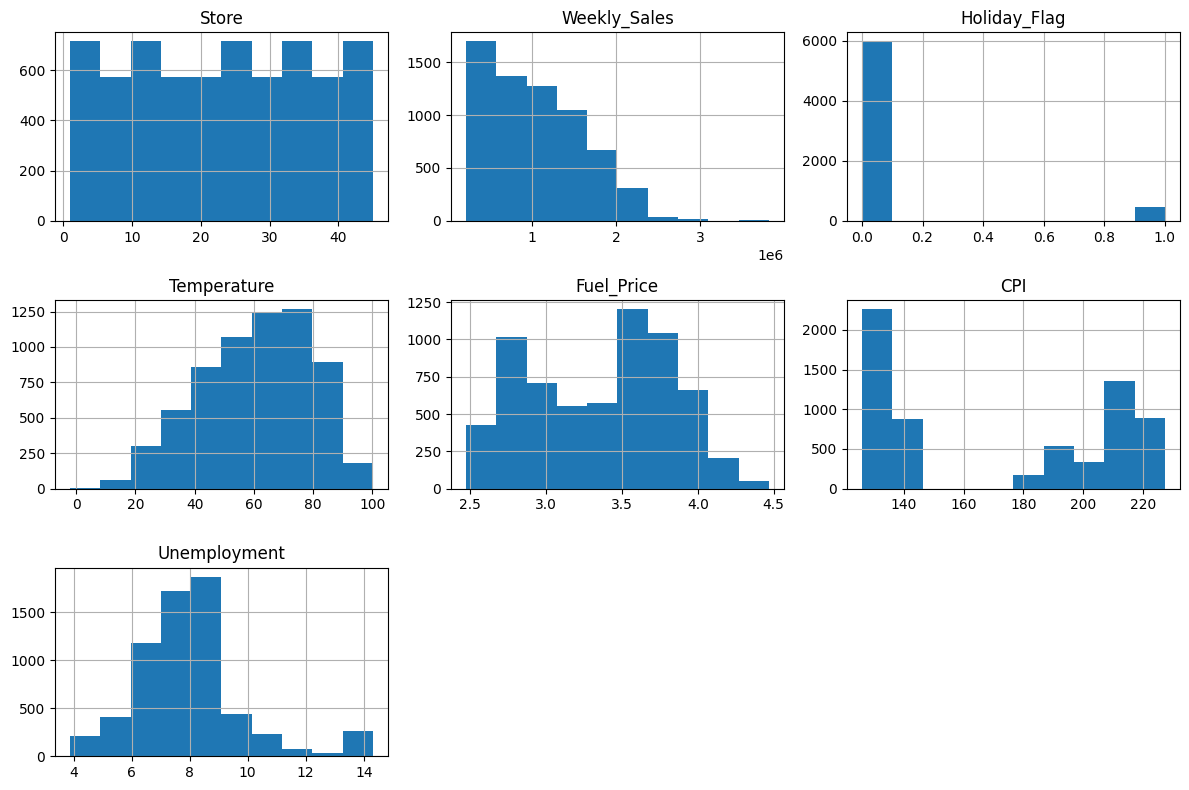

In [ ]:
import matplotlib.pyplot as plt

df_walmart.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

In [ ]:
df_walmart['Date'] = pd.to_datetime(df_walmart['Date'],dayfirst=True)
df_walmart = df_walmart.sort_values(by = 'Date', ascending= True)

In [ ]:
df_eda = df_walmart.copy()
df_tree = df_walmart.copy()
df_scaled = df_walmart.copy()

In [ ]:
#df_eda['Date'] = pd.to_datetime(df_eda['Date'],dayfirst=True)

df_eda['Year'] = df_eda['Date'].dt.year
df_eda['Month'] = df_eda['Date'].dt.month
df_eda['Week'] = df_eda['Date'].dt.isocalendar().week

In [ ]:
df_eda.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6435 entries, 0 to 6434
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
 8   Year          6435 non-null   int32         
 9   Month         6435 non-null   int32         
 10  Week          6435 non-null   UInt32        
dtypes: UInt32(1), datetime64[ns](1), float64(5), int32(2), int64(2)
memory usage: 534.2 KB


# **EDA**

## Correlation

look at the relationship between predictors and target

no variable has strong relationship. Shows need for complex models

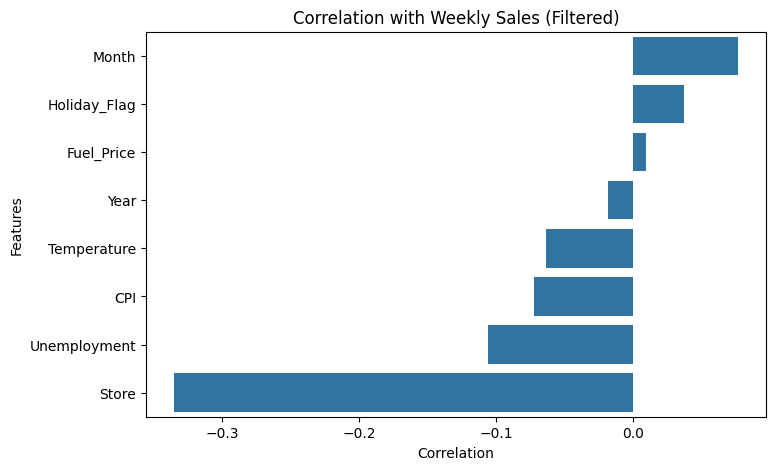

In [81]:
# Correlation of all numeric variables with Weekly_Sales

corr_with_sales = df_eda.corr(numeric_only=True)['Weekly_Sales'].sort_values(ascending=False)

# Drop Weekly_Sales and Store
corr_filtered = corr_with_sales.drop(['Weekly_Sales', 'Week'])

# Plot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(x=corr_filtered.values, y=corr_filtered.index)

plt.title("Correlation with Weekly Sales (Filtered)")
plt.xlabel("Correlation")
plt.ylabel("Features")

plt.show()

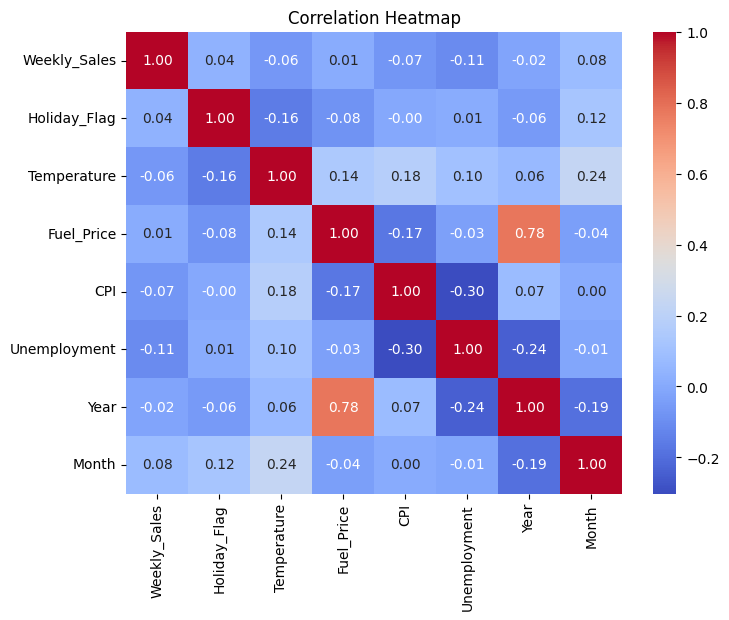

In [82]:
# Select only relevant columns (drop Store)
corr_matrix = df_eda.drop(columns=['Store','Week']).corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

## Target Variable

Plot all Variables Distribution Shape from above

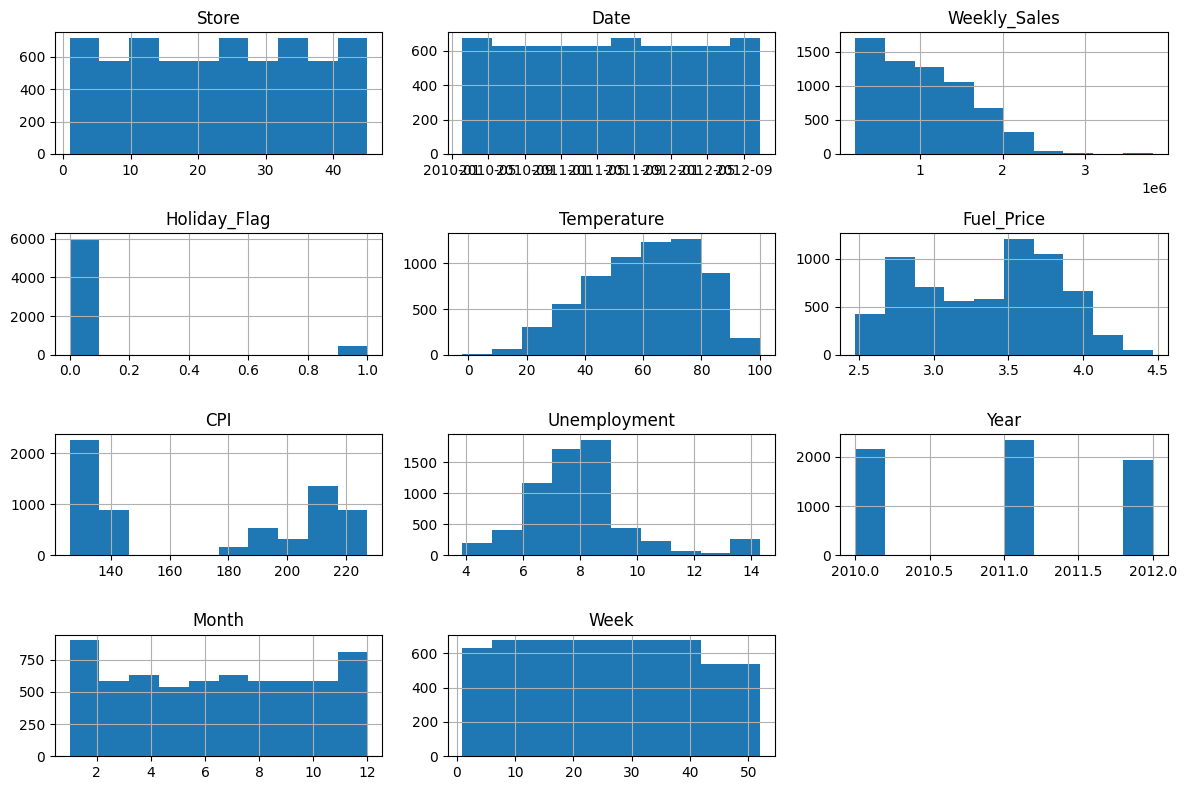

In [83]:
df_eda.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

## Store Level Behaviour

In [84]:
# Average weekly sales per store
avg_sales_per_store = (
    df_eda.groupby('Store')['Weekly_Sales']
    .mean()
    .sort_values(ascending=False)
)

print(avg_sales_per_store)

Store
20    2.107677e+06
4     2.094713e+06
14    2.020978e+06
13    2.003620e+06
2     1.925751e+06
10    1.899425e+06
27    1.775216e+06
6     1.564728e+06
1     1.555264e+06
39    1.450668e+06
19    1.444999e+06
31    1.395901e+06
23    1.389864e+06
24    1.356755e+06
11    1.356383e+06
28    1.323522e+06
41    1.268125e+06
32    1.166568e+06
18    1.084718e+06
22    1.028501e+06
12    1.009002e+06
26    1.002912e+06
34    9.667816e+05
40    9.641280e+05
35    9.197250e+05
8     9.087495e+05
17    8.935814e+05
45    7.859814e+05
21    7.560691e+05
25    7.067215e+05
43    6.333247e+05
15    6.233125e+05
7     5.706173e+05
42    5.564039e+05
9     5.439806e+05
29    5.394514e+05
16    5.192477e+05
37    5.189003e+05
30    4.385796e+05
3     4.027044e+05
38    3.857317e+05
36    3.735120e+05
5     3.180118e+05
44    3.027489e+05
33    2.598617e+05
Name: Weekly_Sales, dtype: float64


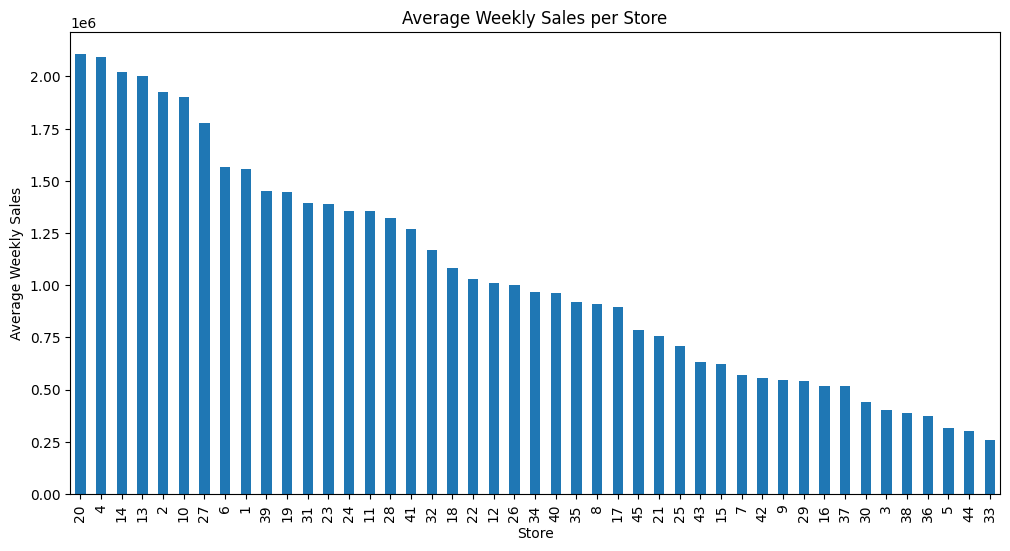

In [85]:
avg_sales_per_store.plot(kind='bar', figsize=(12,6))
plt.title('Average Weekly Sales per Store')
plt.xlabel('Store')
plt.ylabel('Average Weekly Sales')
plt.show()

HUGE Variation Across Stores • Top stores ≈ 2.1M • Bottom stores ≈ 0.3M

That’s a massive gap (7x difference)

Creates two groups of best performers and worst performers

In [112]:
best_performers = avg_sales_per_store.head(2)
worst_performers = avg_sales_per_store.tail(2)

In [113]:
top_data = df_eda[df_eda['Store'].isin(best_performers.index)]
bottom_data = df_eda[df_eda['Store'].isin(worst_performers.index)]

Best stores growth performance

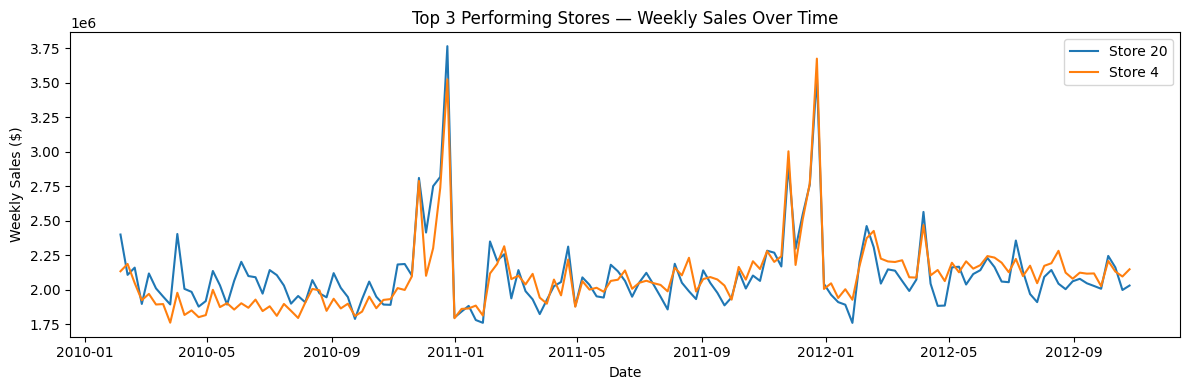

In [115]:
plt.figure(figsize=(12, 4))
for store in best_performers.index:
    store_data = top_data[top_data['Store'] == store].sort_values('Date')
    plt.plot(store_data['Date'], store_data['Weekly_Sales'], label=f'Store {store}')
plt.title("Top 3 Performing Stores — Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Weekly Sales ($)")
plt.legend()
plt.tight_layout()
plt.show()

Worst stores growth performance

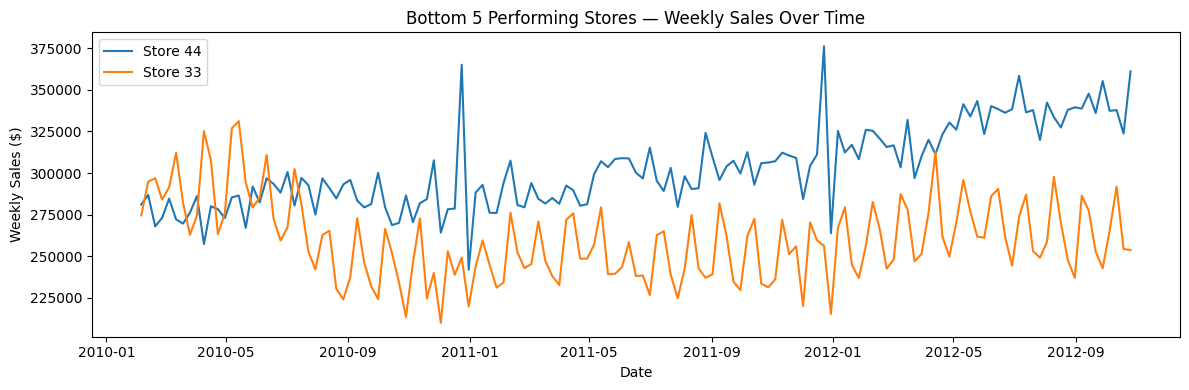

In [116]:
plt.figure(figsize=(12, 4))
for store in worst_performers.index:
    store_data = bottom_data[bottom_data['Store'] == store].sort_values('Date')
    plt.plot(store_data['Date'], store_data['Weekly_Sales'], label=f'Store {store}')
plt.title("Bottom 5 Performing Stores — Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Weekly Sales ($)")
plt.legend()
plt.tight_layout()
plt.show()

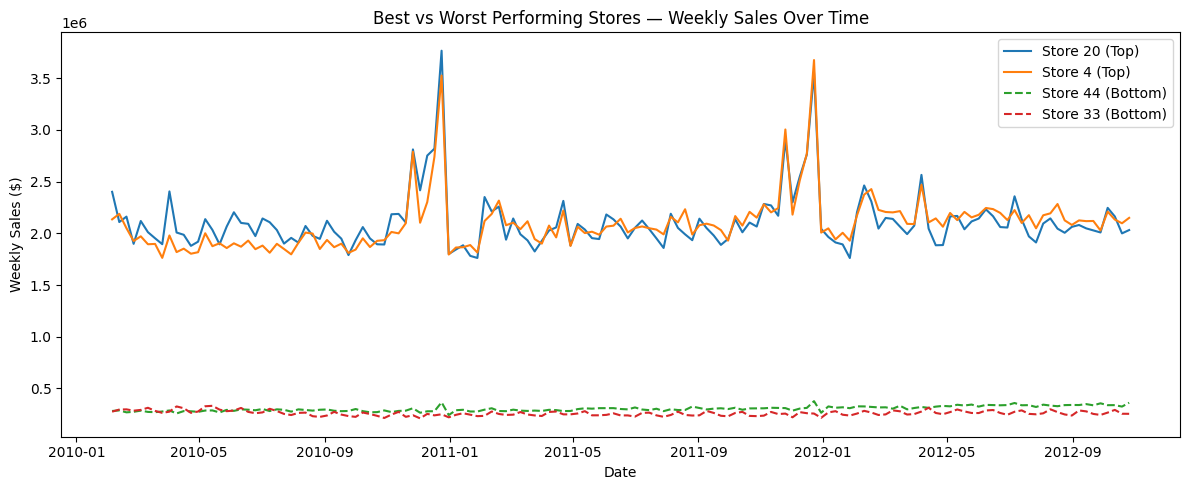

In [114]:
plt.figure(figsize=(12, 5))

for store in best_performers.index:
    store_data = top_data[top_data['Store'] == store].sort_values('Date')
    plt.plot(store_data['Date'], store_data['Weekly_Sales'], label=f'Store {store} (Top)', linestyle='-')

for store in worst_performers.index:
    store_data = bottom_data[bottom_data['Store'] == store].sort_values('Date')
    plt.plot(store_data['Date'], store_data['Weekly_Sales'], label=f'Store {store} (Bottom)', linestyle='--')

plt.title("Best vs Worst Performing Stores — Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Weekly Sales ($)")
plt.legend()
plt.tight_layout()
plt.show()

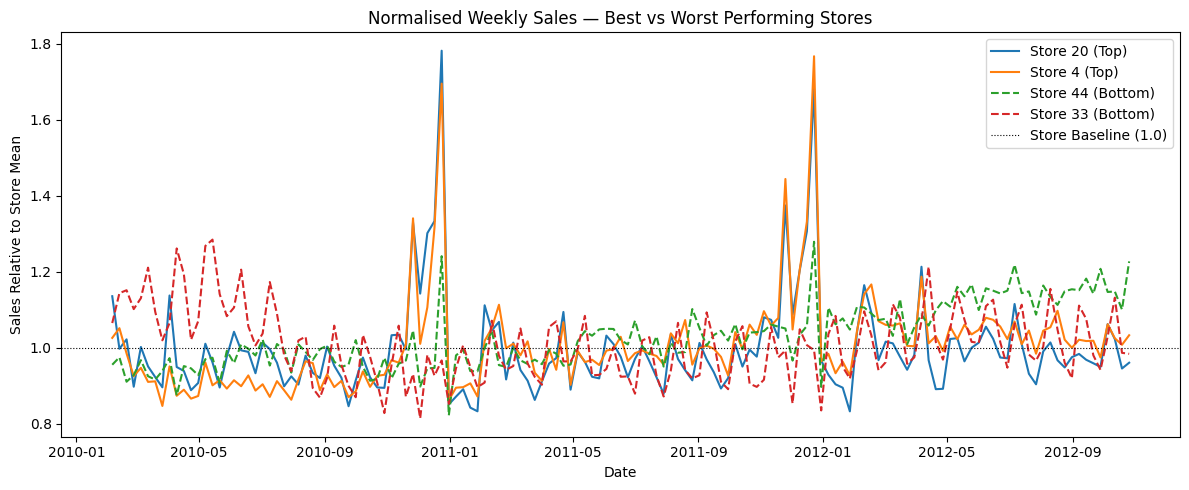

In [124]:
# Store means calculated from training data only to avoid leakage
store_means = df_eda.iloc[:int(len(df_eda) * 0.8)].groupby('Store')['Weekly_Sales'].mean()

# Add to df_eda for visualisation
df_eda['Store_Mean_Sales'] = df_eda['Store'].map(store_means)
df_eda['Weekly_Sales_Normalised'] = df_eda['Weekly_Sales'] / df_eda['Store_Mean_Sales']

# Plot the same top 2 and bottom 2 stores on normalised scale
plt.figure(figsize=(12, 5))

for store in best_performers.index:
    store_data = df_eda[df_eda['Store'] == store].sort_values('Date')
    plt.plot(store_data['Date'], store_data['Weekly_Sales_Normalised'], label=f'Store {store} (Top)', linestyle='-')

for store in worst_performers.index:
    store_data = df_eda[df_eda['Store'] == store].sort_values('Date')
    plt.plot(store_data['Date'], store_data['Weekly_Sales_Normalised'], label=f'Store {store} (Bottom)', linestyle='--')

plt.axhline(1.0, color='black', linewidth=0.8, linestyle=':', label='Store Baseline (1.0)')
plt.title("Normalised Weekly Sales — Best vs Worst Performing Stores")
plt.xlabel("Date")
plt.ylabel("Sales Relative to Store Mean")
plt.legend()
plt.tight_layout()
plt.show()

## Time based Exploration

Plot sales over time (overall and per store)

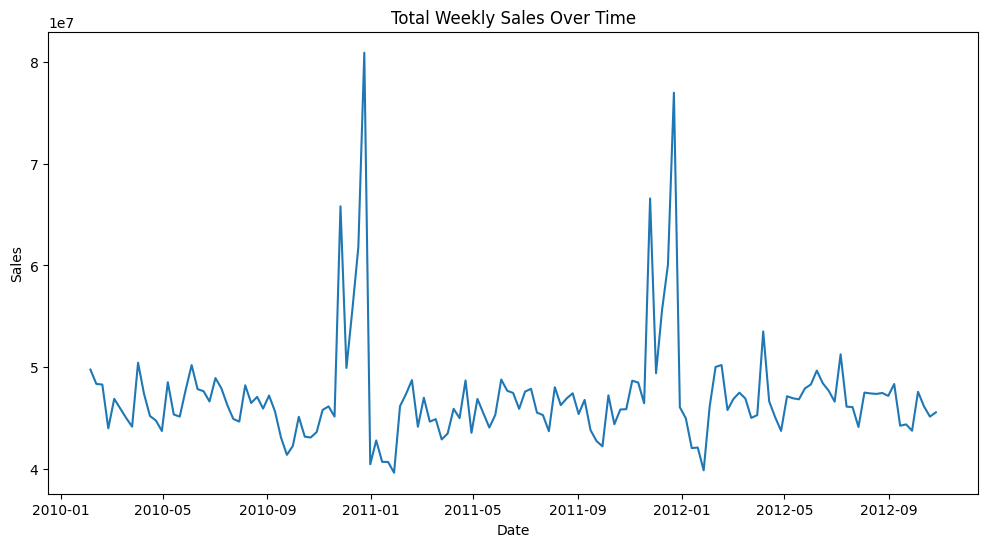

In [89]:
# Aggregate total sales per week
weekly_sales = df_eda.groupby('Date')['Weekly_Sales'].sum()

# Plot trend
plt.figure(figsize=(12,6))
plt.plot(weekly_sales)
plt.title("Total Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

Match with your Kaggle info:
	•	Nov → Thanksgiving 🦃
	•	Dec → Christmas 🎄
	•	Feb → Super Bowl 🏈

💡 These spikes line up perfectly with major retail events

confirms seasonality

**How do Holiday Sales look compared to Non Holiday Sales?**

May be due to extreme class imbalnce , funny how theres not much difference even though only holiday flags make up for 6.9% of days across the whole dataset

In [90]:
holidays = df_eda['Holiday_Flag'].value_counts(normalize=True) * 100
holidays

,proportion
Holiday_Flag,
0,93.006993
1,6.993007


In [91]:
holiday_sales = df_eda.groupby('Holiday_Flag')['Weekly_Sales'].mean()

holiday_sales

,Weekly_Sales
Holiday_Flag,
0,1.041256e+06
1,1.122888e+06


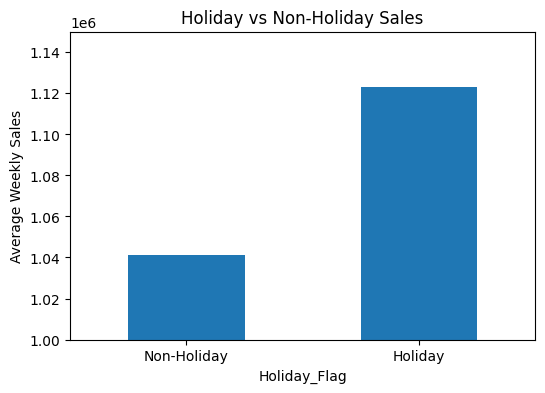

In [121]:
holiday_sales.plot(kind='bar', figsize=(6,4))
plt.title("Holiday vs Non-Holiday Sales")
plt.ylabel("Average Weekly Sales")
plt.xticks([0,1], ['Non-Holiday', 'Holiday'], rotation=0)
plt.ylim(1000000, 1150000)
plt.show()

**“Do strong stores benefit more from holidays than weak ones?”**

More of a significant difference between holidays and not holiday of top stores than weak stores.

In [93]:
top_holiday = top_data.groupby('Holiday_Flag')['Weekly_Sales'].mean()
bottom_holiday = bottom_data.groupby('Holiday_Flag')['Weekly_Sales'].mean()

print("Top Stores:\n", top_holiday)
print("\nBottom Stores:\n", bottom_holiday)

Top Stores:
 Holiday_Flag
0    2.020739e+06
1    2.161006e+06
Name: Weekly_Sales, dtype: float64

Bottom Stores:
 Holiday_Flag
0    327560.928932
1    333456.447000
Name: Weekly_Sales, dtype: float64


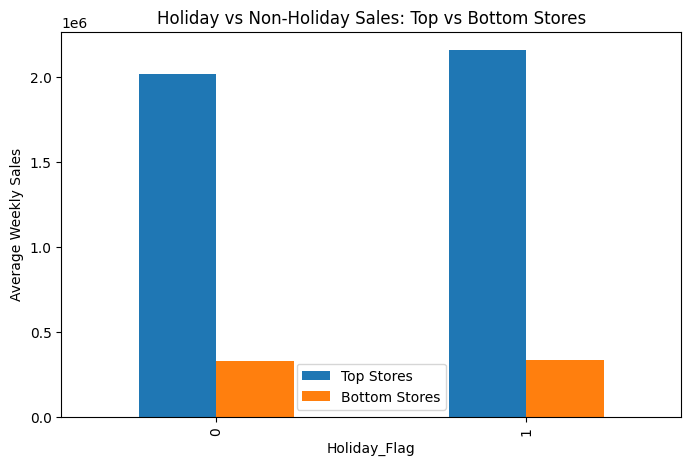

In [94]:
comparison = pd.DataFrame({
    'Top Stores': top_holiday,
    'Bottom Stores': bottom_holiday
})

comparison.plot(kind='bar', figsize=(8,5))
plt.title("Holiday vs Non-Holiday Sales: Top vs Bottom Stores")
plt.ylabel("Average Weekly Sales")
plt.show()

When do sales perform best?

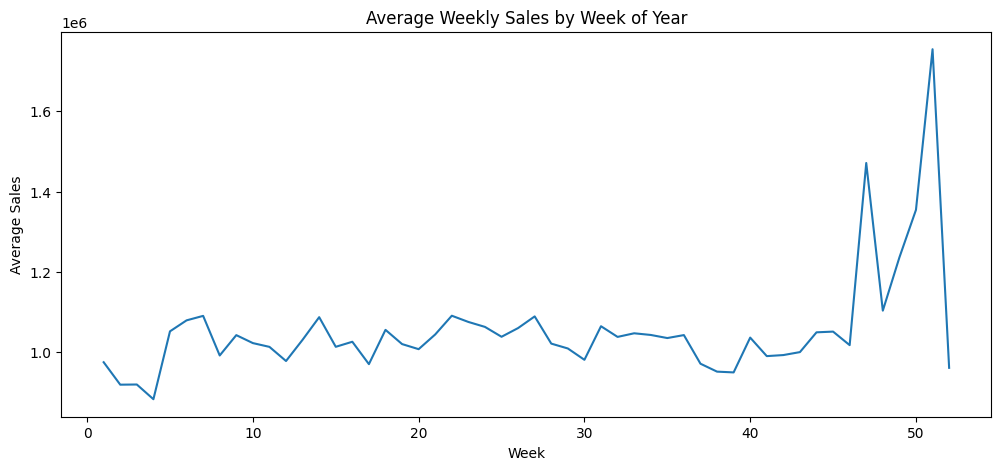

In [95]:
weekly_pattern = df_eda.groupby('Week')['Weekly_Sales'].mean()

weekly_pattern.plot(figsize=(12,5))
plt.title('Average Weekly Sales by Week of Year')
plt.xlabel('Week')
plt.ylabel('Average Sales')
plt.show()

December is the best performing month. Week 45 to 52 the best performing weeks

## Weather Exploration

/tmp/ipykernel_12845/3255650556.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_sales = df_eda.groupby('Temp_Bin')['Weekly_Sales'].mean()


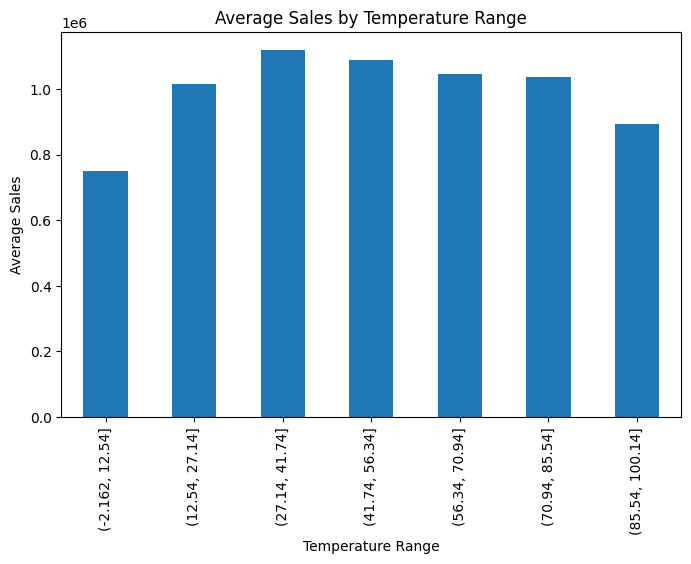

In [96]:
df_eda['Temp_Bin'] = pd.cut(df_eda['Temperature'], bins=7)

temp_sales = df_eda.groupby('Temp_Bin')['Weekly_Sales'].mean()

temp_sales.plot(kind='bar', figsize=(8,5))
plt.title("Average Sales by Temperature Range")
plt.xlabel("Temperature Range")
plt.ylabel("Average Sales")

plt.show()

Lower Sales at Extremes

Very cold (0-12°F) → lower sales

Very hot (85-100°F) → lower sales

Highest sales at moderate temperatures

Sales are highest during moderate temperature ranges; however, this relationship is likely driven by seasonal effects rather than temperature itself, as peak sales coincide with major holiday periods occurring during these conditions.

## Fuel Price Exploration

Does fuel price affect sales?

/tmp/ipykernel_12845/4201200382.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fuel_sales = df_eda.groupby('Fuel_Bin')['Weekly_Sales'].mean()


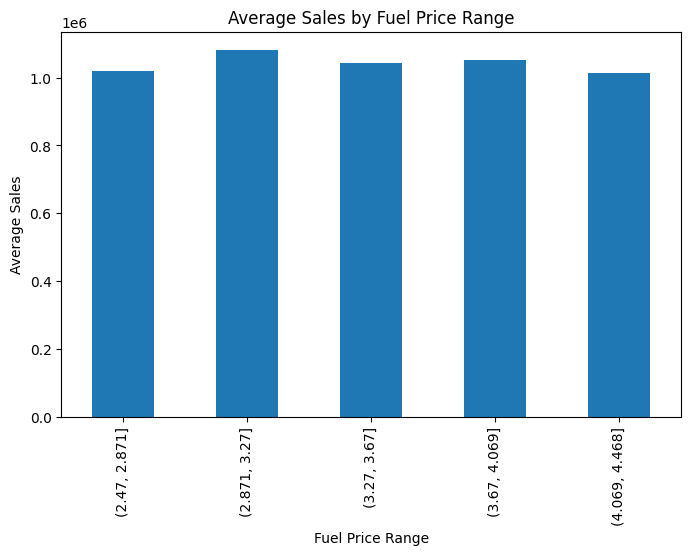

In [97]:
df_eda['Fuel_Bin'] = pd.cut(df_eda['Fuel_Price'], bins=5)

fuel_sales = df_eda.groupby('Fuel_Bin')['Weekly_Sales'].mean()

fuel_sales.plot(kind='bar', figsize=(8,5))
plt.title("Average Sales by Fuel Price Range")
plt.xlabel("Fuel Price Range")
plt.ylabel("Average Sales")

plt.show()

Fuel price shows minimal relationship with weekly sales, suggesting that short-term fluctuations in fuel costs do not significantly influence retail purchasing behaviour in this dataset

## Unemployment

/tmp/ipykernel_12845/640463970.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  unemp_sales = df_eda.groupby('Unemp_Bin')['Weekly_Sales'].mean()


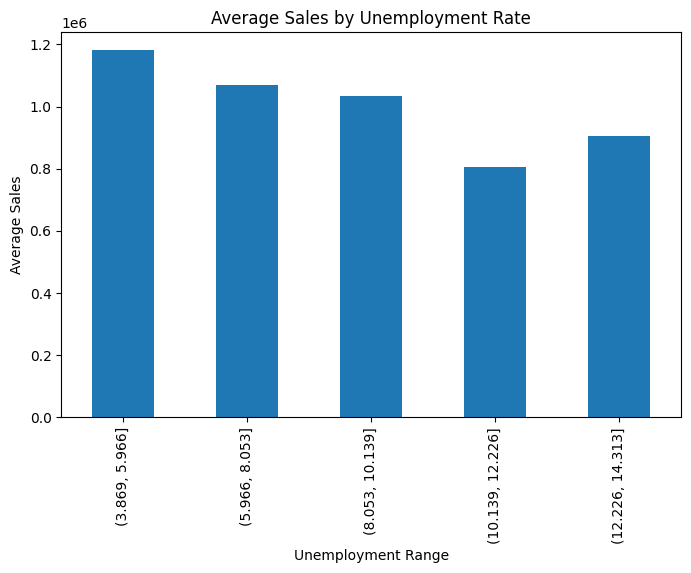

In [98]:
df_eda['Unemp_Bin'] = pd.cut(df_eda['Unemployment'], bins=5)

unemp_sales = df_eda.groupby('Unemp_Bin')['Weekly_Sales'].mean()

unemp_sales.plot(kind='bar', figsize=(8,5))
plt.title("Average Sales by Unemployment Rate")
plt.xlabel("Unemployment Range")
plt.ylabel("Average Sales")

plt.show()

#pre-processing RF, XG, LightGBM, ADAboost - just log tranformation

In [ ]:
df_tree['Date'] = pd.to_datetime(df_tree['Date'],dayfirst=True)

df_tree['Year'] = df_tree['Date'].dt.year
df_tree['Month'] = df_tree['Date'].dt.month
df_tree['Week'] = df_tree['Date'].dt.isocalendar().week

In [ ]:
df_tree['Month_sin'] = np.sin(2 * np.pi * df_tree['Month'] / 12)
df_tree['Month_cos'] = np.cos(2 * np.pi * df_tree['Month'] / 12)

df_tree['Week_sin'] = np.sin(2 * np.pi * df_tree['Week'] / 52)
df_tree['Week_cos'] = np.cos(2 * np.pi * df_tree['Week'] / 52)

In [ ]:
df_tree.drop(['Month', 'Week', 'Date'], axis=1, inplace=True)

In [ ]:
df_tree.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6435 entries, 0 to 6434
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Weekly_Sales  6435 non-null   float64
 2   Holiday_Flag  6435 non-null   int64  
 3   Temperature   6435 non-null   float64
 4   Fuel_Price    6435 non-null   float64
 5   CPI           6435 non-null   float64
 6   Unemployment  6435 non-null   float64
 7   Year          6435 non-null   int32  
 8   Month_sin     6435 non-null   float64
 9   Month_cos     6435 non-null   float64
 10  Week_sin      6435 non-null   Float64
 11  Week_cos      6435 non-null   Float64
dtypes: Float64(2), float64(7), int32(1), int64(2)
memory usage: 641.0 KB


In [ ]:
df_tree['Store'] = df_tree['Store'].astype('category')
df_tree['Holiday_Flag'] = df_tree['Holiday_Flag'].astype('category')

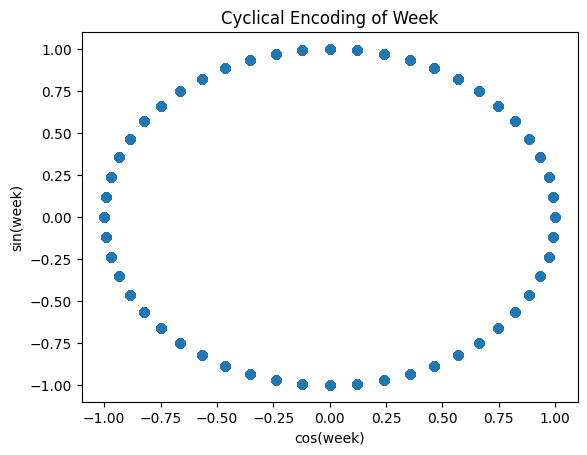

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df_tree['Week_cos'], df_tree['Week_sin'])
plt.xlabel('cos(week)')
plt.ylabel('sin(week)')
plt.title('Cyclical Encoding of Week')
plt.show()

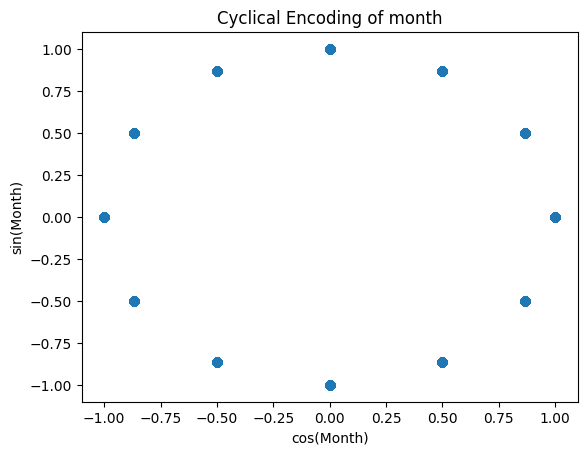

In [ ]:
plt.figure()
plt.scatter(df_tree['Month_cos'], df_tree['Month_sin'])
plt.xlabel('cos(Month)')
plt.ylabel('sin(Month)')
plt.title('Cyclical Encoding of month')
plt.show()

In [ ]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop='first', sparse_output=False)

encoded = encoder.fit_transform(df_tree[['Store', 'Year']])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(['Store', 'Year'])
)

df_tree= pd.concat([df_tree.drop(['Store', 'Year'], axis=1), encoded_df], axis=1)

# pre-processing MLR, SVM and NN - includes scaling and log transformation

all numerical features where scaled, weekly wales was log transformed then scaled to deal with skew

In [ ]:
df_scaled['Weekly_Sales'] = np.log1p(df_scaled['Weekly_Sales'])

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# A dedicated scaler kept just for the target so we can inverse transform later
sales_scaler = StandardScaler()

df_scaled['Weekly_Sales_scaled']  = sales_scaler.fit_transform(df_scaled[['Weekly_Sales']])
df_scaled['Temperature_scaled']   = scaler.fit_transform(df_scaled[['Temperature']])
df_scaled['Fuel_Price_scaled']    = scaler.fit_transform(df_scaled[['Fuel_Price']])
df_scaled['CPI_scaled']           = scaler.fit_transform(df_scaled[['CPI']])
df_scaled['Unemployment_scaled']  = scaler.fit_transform(df_scaled[['Unemployment']])

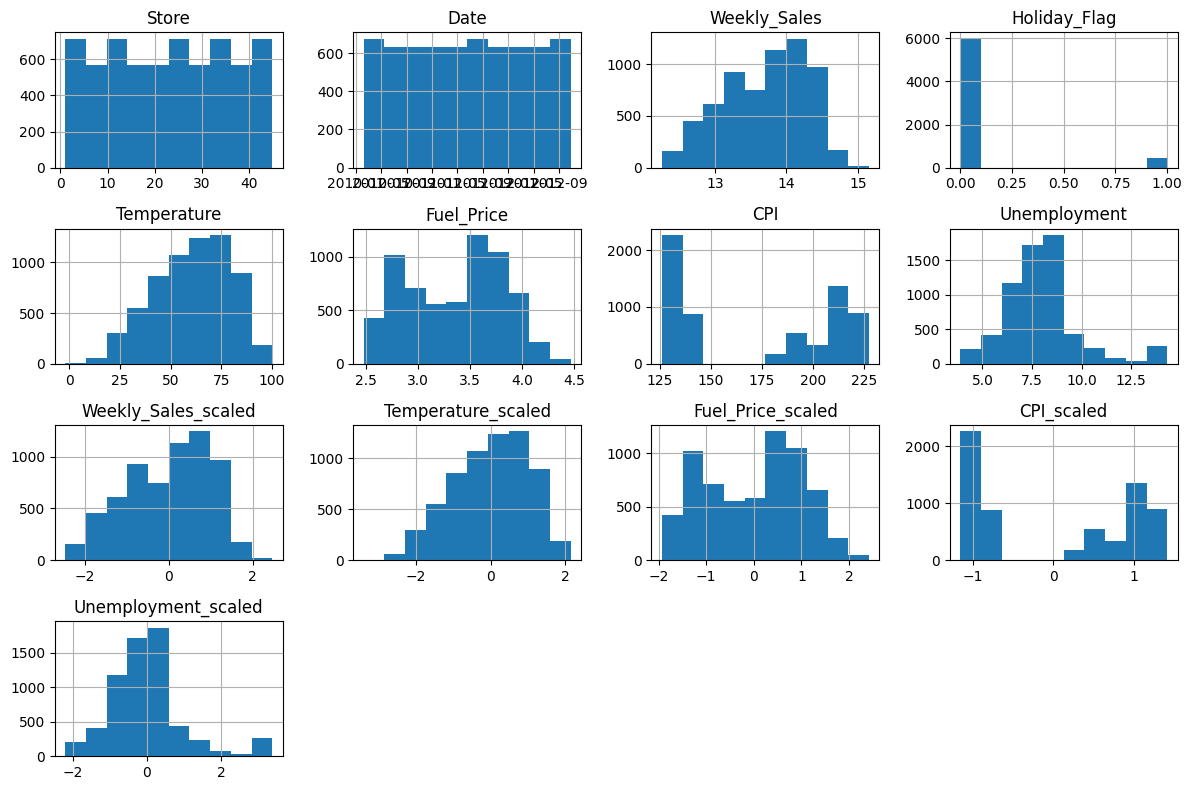

In [ ]:
df_scaled.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

date time processing

In [ ]:
df_scaled['Date'] = pd.to_datetime(df_scaled['Date'],dayfirst=True)

df_scaled['Year'] = df_scaled['Date'].dt.year
df_scaled['Month'] = df_scaled['Date'].dt.month
df_scaled['Week'] = df_scaled['Date'].dt.isocalendar().week

In [ ]:
df_scaled['Month_sin'] = np.sin(2 * np.pi * df_scaled['Month'] / 12)
df_scaled['Month_cos'] = np.cos(2 * np.pi * df_scaled['Month'] / 12)

df_scaled['Week_sin'] = np.sin(2 * np.pi * df_scaled['Week'] / 52)
df_scaled['Week_cos'] = np.cos(2 * np.pi * df_scaled['Week'] / 52)

In [ ]:
df_scaled.drop(['Date','Month','Week','Weekly_Sales','Temperature','Fuel_Price','Unemployment'], axis=1, inplace=True)

In [ ]:
df_scaled.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6435 entries, 0 to 6434
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Store                6435 non-null   int64  
 1   Holiday_Flag         6435 non-null   int64  
 2   CPI                  6435 non-null   float64
 3   Weekly_Sales_scaled  6435 non-null   float64
 4   Temperature_scaled   6435 non-null   float64
 5   Fuel_Price_scaled    6435 non-null   float64
 6   CPI_scaled           6435 non-null   float64
 7   Unemployment_scaled  6435 non-null   float64
 8   Year                 6435 non-null   int32  
 9   Month_sin            6435 non-null   float64
 10  Month_cos            6435 non-null   float64
 11  Week_sin             6435 non-null   Float64
 12  Week_cos             6435 non-null   Float64
dtypes: Float64(2), float64(8), int32(1), int64(2)
memory usage: 949.3 KB


In [ ]:
df_scaled.head(1)

,Store,Holiday_Flag,CPI,Weekly_Sales_scaled,Temperature_scaled,Fuel_Price_scaled,CPI_scaled,Unemployment_scaled,Year,Month_sin,Month_cos,Week_sin,Week_cos
0,1,0,211.096358,1.037892,-0.995136,-1.7138,1.004175,0.056964,2010,0.866025,0.5,0.568065,0.822984


In [ ]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop='first', sparse_output=False)

encoded = encoder.fit_transform(df_scaled[['Store', 'Year']])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(['Store', 'Year'])
)

df_scaled= pd.concat([df_scaled.drop(['Store', 'Year'], axis=1), encoded_df], axis=1)

# Tree - baselines

In [ ]:
# Features and target
X = df_tree.drop('Weekly_Sales', axis=1)
y = df_tree['Weekly_Sales']

# Split index (80%)
split_index = int(len(df_tree) * 0.8)

# Train = first 80%, Test = last 20%
X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

print(X_train.shape, X_test.shape)

(5148, 55) (1287, 55)


## XGBoost

In [ ]:
from xgboost import XGBRegressor

xgmodel = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror',
    n_jobs=-1,
    enable_categorical = True
)

xgmodel.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = xgmodel.predict(X_test)

xgb_mae = mean_absolute_error(y_test, y_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
xgb_r2 = r2_score(y_test, y_pred)

print("MAE:", xgb_mae)
print("RMSE:", xgb_rmse)
print("R2:", xgb_r2)


MAE: 322475.57412053226
RMSE: 414922.0220190372
R2: 0.39390108544157587


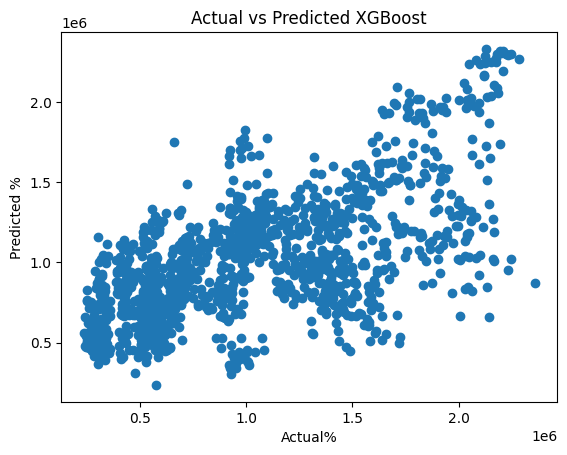

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual%")
plt.ylabel("Predicted %")
plt.title("Actual vs Predicted XGBoost")
plt.show()

## LightGBM

In [ ]:
!pip install lightgbm

import lightgbm as lgb

In [ ]:
model_lgb = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=7,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=1,
    min_data_in_leaf=20
)

model_lgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='mae',
    callbacks=[lgb.early_stopping(stopping_rounds=100)]
)

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Info] Auto-choosing row-wise multi-threading, 

LGBMRegressor(bagging_fraction=0.8, bagging_freq=1, feature_fraction=0.8,
              learning_rate=0.05, max_depth=7, min_data_in_leaf=20,
              n_estimators=500)

In [ ]:
y_pred = model_lgb.predict(X_test)

lgb_mae = mean_absolute_error(y_test, y_pred)
lgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
lgb_r2 = r2_score(y_test, y_pred)

print("MAE:", lgb_mae)
print("RMSE:", lgb_rmse)
print("R2:", lgb_r2)

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
MAE: 329705.44029403664
RMSE: 414998.63760636415
R2: 0.39367723175762015


In [ ]:
y_pred = model_lgb.predict(X_test)

lgb_mae = mean_absolute_error(y_test, y_pred)
lgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
lgb_r2 = r2_score(y_test, y_pred)

print("MAE:", lgb_mae)
print("RMSE:", lgb_rmse)
print("R2:", lgb_r2)

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
MAE: 329705.44029403664
RMSE: 414998.63760636415
R2: 0.39367723175762015


## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=600,
    max_depth=30,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=30, max_features='sqrt', min_samples_leaf=2,
                      min_samples_split=5, n_estimators=600, n_jobs=-1,
                      random_state=42)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, y_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rf_r2 = r2_score(y_test, y_pred)

print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)

MAE: 339132.0250246281
RMSE: 408522.19165779493
R2: 0.41245404421171816


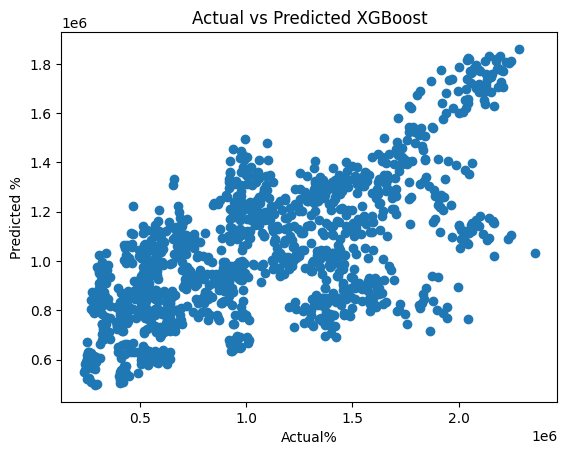

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual%")
plt.ylabel("Predicted %")
plt.title("Actual vs Predicted XGBoost")
plt.show()

## ADABoost

In [ ]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor

# Base learner for AdaBoost
base_model = DecisionTreeRegressor(max_depth=4, random_state=42)

# AdaBoost Regressor
ada_model = AdaBoostRegressor(
    estimator=base_model,
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

# Train the model
ada_model.fit(X_train, y_train)

# Make predictions
y_pred = ada_model.predict(X_test)

# Evaluation metrics
ada_mae = mean_absolute_error(y_test, y_pred)
ada_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
ada_r2 = r2_score(y_test, y_pred)

print("AdaBoost Regression Results")
print(f"MAE: {ada_mae:.2f}")
print(f"RMSE: {ada_rmse:.2f}")
print(f"R²: {ada_r2:.4f}")

AdaBoost Regression Results
MAE: 385361.13
RMSE: 455438.51
R²: 0.2698


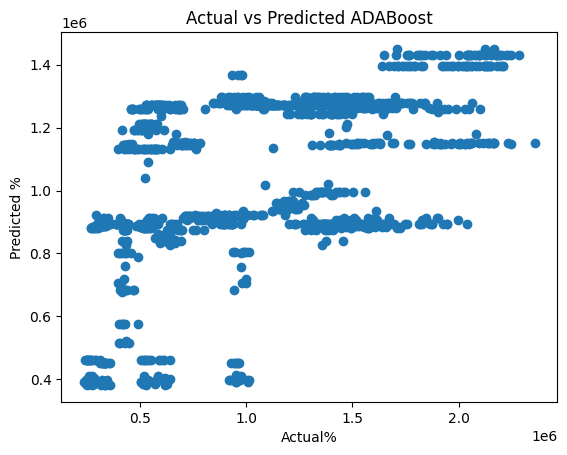

In [ ]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual%")
plt.ylabel("Predicted %")
plt.title("Actual vs Predicted ADABoost")
plt.show()

#Scaled baselines

In [ ]:
def inverse_transform(y_pred_scaled):
    y_pred_log = sales_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    return np.expm1(y_pred_log)

def evaluate_metrics(name, y_test, y_pred):
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    print(f"--- {name} ---")
    print(f"  MAE  : {mae:,.2f}")
    print(f"  RMSE : {rmse:,.2f}")
    print(f"  R²   : {r2:.4f}\n")

def plot_predictions(name, y_test, y_pred):
    plt.figure()
    plt.scatter(y_test, y_pred)
    plt.xlabel("Actual Weekly Sales ($)")
    plt.ylabel("Predicted Weekly Sales ($)")
    plt.title(name)
    plt.tight_layout()
    plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

split_idx = int(len(df_scaled) * 0.8)

X_scaled = df_scaled.drop(columns=['Weekly_Sales_scaled'])
y_scaled = df_scaled['Weekly_Sales_scaled']

X_scaled_train, X_scaled_test = X_scaled.iloc[:split_idx], X_scaled.iloc[split_idx:]
y_scaled_train, y_scaled_test = y_scaled.iloc[:split_idx], y_scaled.iloc[split_idx:]

# Compute actuals in dollars once
y_test_dollars = inverse_transform(y_scaled_test.values)

print(f"Train size: {len(X_scaled_train)} | Test size: {len(X_scaled_test)}")

Train size: 5148 | Test size: 1287


--- Multiple Linear Regression (Baseline) ---
  MAE  : 417,687.13
  RMSE : 505,588.32
  R²   : 0.1001



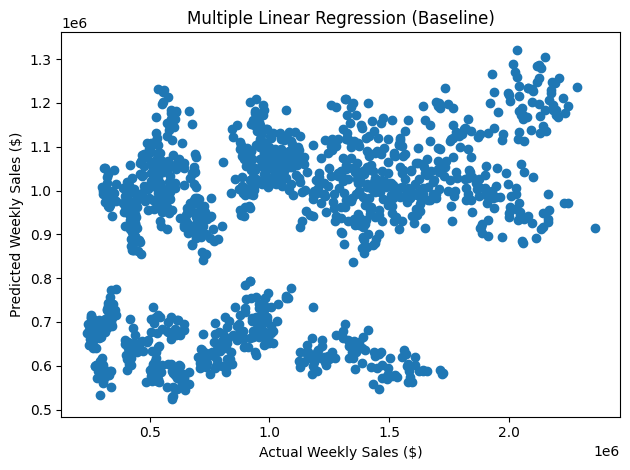

In [ ]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_scaled_train, y_scaled_train)
y_pred_lr = inverse_transform(lr_model.predict(X_scaled_test))

evaluate_metrics("Multiple Linear Regression (Baseline)", y_test_dollars, y_pred_lr)
plot_predictions("Multiple Linear Regression (Baseline)", y_test_dollars, y_pred_lr)


--- SVR - RBF Kernel (Baseline) ---
  MAE  : 435,539.61
  RMSE : 548,701.29
  R²   : -0.0599



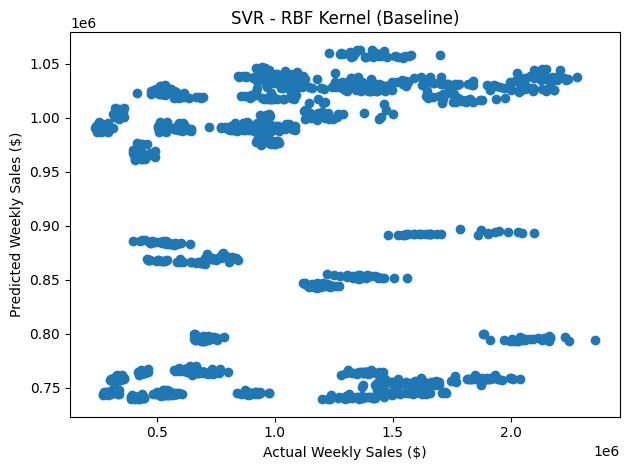

In [ ]:
from sklearn.svm import SVR

svr_model = SVR(kernel='rbf')
svr_model.fit(X_scaled_train, y_scaled_train)
y_pred_svr = inverse_transform(svr_model.predict(X_scaled_test))

evaluate_metrics("SVR - RBF Kernel (Baseline)", y_test_dollars, y_pred_svr)
plot_predictions("SVR - RBF Kernel (Baseline)", y_test_dollars, y_pred_svr)

--- Neural Network - MLP (Baseline) ---
  MAE  : 398,762.09
  RMSE : 496,006.12
  R²   : 0.1339



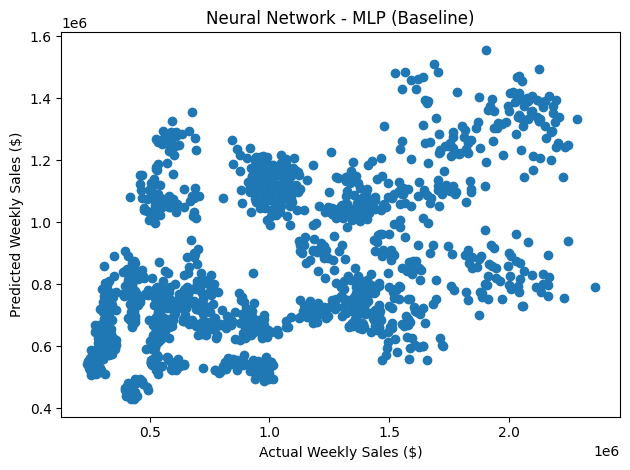

In [ ]:
from sklearn.neural_network import MLPRegressor

nn_model = MLPRegressor(
    hidden_layer_sizes=(64, 32),  # 2-layer baseline architecture
    activation='relu',
    max_iter=500,
    random_state=42
)
nn_model.fit(X_scaled_train, y_scaled_train)
y_pred_nn = inverse_transform(nn_model.predict(X_scaled_test))

evaluate_metrics("Neural Network - MLP (Baseline)", y_test_dollars, y_pred_nn)
plot_predictions("Neural Network - MLP (Baseline)", y_test_dollars, y_pred_nn)


# Baseline Comparison Table

In [ ]:
# Baseline Comparison Table
# Note: tree model metrics are already in dollars, scaled model metrics use y_test_dollars

baseline_results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'SVR',
        'Neural Network (MLP)',
        'Random Forest',
        'XGBoost',
        'LightGBM',
        'ADABoost'
    ],
    'MAE ($)': [
        mean_absolute_error(y_test_dollars, y_pred_lr),
        mean_absolute_error(y_test_dollars, y_pred_svr),
        mean_absolute_error(y_test_dollars, y_pred_nn),
        rf_mae,
        xgb_mae,
        lgb_mae,
        ada_mae
    ],
    'RMSE ($)': [
        np.sqrt(mean_squared_error(y_test_dollars, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test_dollars, y_pred_svr)),
        np.sqrt(mean_squared_error(y_test_dollars, y_pred_nn)),
        rf_rmse,
        xgb_rmse,
        lgb_rmse,
        ada_rmse
    ],
    'R²': [
        r2_score(y_test_dollars, y_pred_lr),
        r2_score(y_test_dollars, y_pred_svr),
        r2_score(y_test_dollars, y_pred_nn),
        rf_r2,
        xgb_r2,
        lgb_r2,
        ada_r2
    ]
})

baseline_results = baseline_results.sort_values('R²', ascending=False).reset_index(drop=True)
baseline_results['MAE ($)'] = baseline_results['MAE ($)'].map('{:,.2f}'.format)
baseline_results['RMSE ($)'] = baseline_results['RMSE ($)'].map('{:,.2f}'.format)
baseline_results['R²'] = baseline_results['R²'].map('{:.4f}'.format)

baseline_results = baseline_results.sort_values('R²', ascending=False).reset_index(drop=True)
baseline_results

,Model,MAE ($),RMSE ($),R²
0,Random Forest,"339,132.03","408,522.19",0.4125
1,XGBoost,"322,475.57","414,922.02",0.3939
2,LightGBM,"329,705.44","414,998.64",0.3937
3,ADABoost,"385,361.13","455,438.51",0.2698
4,Neural Network (MLP),"398,762.09","496,006.12",0.1339
5,Linear Regression,"417,687.13","505,588.32",0.1001
6,SVR,"435,539.61","548,701.29",-0.0599


#Hyperparameter Tuning

In [ ]:
!pip install Optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.0 MB/s eta 0:00:00


#Random Forest Tuned

In [ ]:
import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 10, 100),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'random_state': 42,
        'n_jobs': -1
    }

    model = RandomForestRegressor(**params)

    scores = cross_val_score(
        model, X_train, y_train,
        cv=5, scoring='neg_root_mean_squared_error'
    )
    return -scores.mean()

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20, show_progress_bar=True)

print("Best params:", study.best_params)
print(f"Best CV RMSE: {study.best_value:.4f}")

  0%|          | 0/20 [00:00<?, ?it/s]

Best params: {'n_estimators': 565, 'max_depth': 43, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
Best CV RMSE: 418506.5633


--- Random Forest (Tuned) ---
  MAE  : 329,845.45
  RMSE : 401,885.92
  R²   : 0.4314



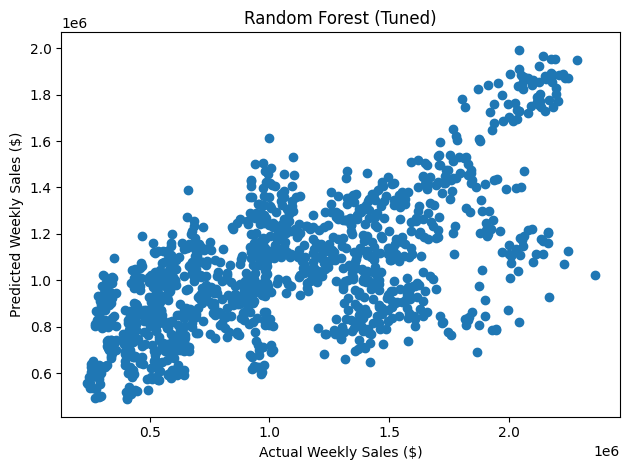

In [ ]:
best_rf = RandomForestRegressor(
    **study.best_params,
    random_state=42,
    n_jobs=-1
)
best_rf.fit(X_train, y_train)
y_pred_rf_tuned = best_rf.predict(X_test)

evaluate_metrics("Random Forest (Tuned)", y_test, y_pred_rf_tuned)
plot_predictions("Random Forest (Tuned)", y_test, y_pred_rf_tuned)

#XGBoost Tuned

In [ ]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'random_state': 42,
        'n_jobs': -1
    }

    model = XGBRegressor(**params)

    scores = cross_val_score(
        model, X_train, y_train,
        cv=5, scoring='neg_root_mean_squared_error'
    )
    return -scores.mean()


X_train['Holiday_Flag'] = X_train['Holiday_Flag'].astype(int)
X_test['Holiday_Flag'] = X_test['Holiday_Flag'].astype(int)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20, show_progress_bar=True)

print("Best params:", study.best_params)
print(f"Best CV RMSE: {study.best_value:.4f}")

/tmp/ipykernel_12845/656981633.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['Holiday_Flag'] = X_train['Holiday_Flag'].astype(int)
/tmp/ipykernel_12845/656981633.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test['Holiday_Flag'] = X_test['Holiday_Flag'].astype(int)


  0%|          | 0/20 [00:00<?, ?it/s]

Best params: {'n_estimators': 795, 'max_depth': 8, 'learning_rate': 0.010607466843760108, 'subsample': 0.5851066861606534, 'colsample_bytree': 0.9303886161669026}
Best CV RMSE: 376154.8525


--- XGBoost (Tuned) ---
  MAE  : 313,769.35
  RMSE : 400,185.43
  R²   : 0.4362



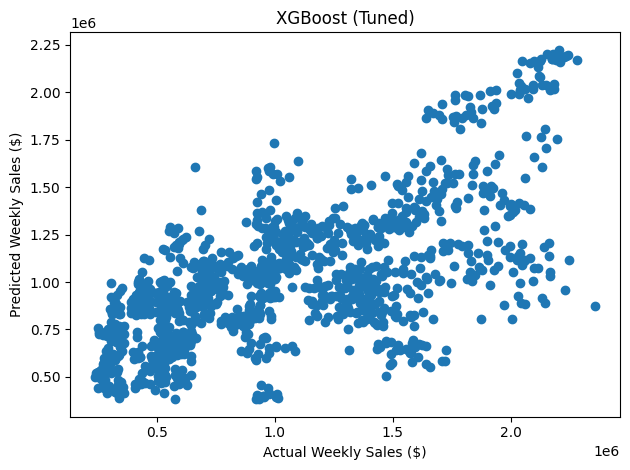

In [ ]:
best_xgb = XGBRegressor(
    **study.best_params,
    random_state=42,
    n_jobs=-1
)
best_xgb.fit(X_train, y_train)
y_pred_xgb_tuned = best_xgb.predict(X_test)

evaluate_metrics("XGBoost (Tuned)", y_test, y_pred_xgb_tuned)
plot_predictions("XGBoost (Tuned)", y_test, y_pred_xgb_tuned)

#LightGBM Tuned

In [ ]:
import optuna
from lightgbm import LGBMRegressor
from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 10),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 10, 60),
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }

    model = LGBMRegressor(**params)

    scores = cross_val_score(
        model, X_train, y_train,
        cv=5, scoring='neg_root_mean_squared_error'
    )
    return -scores.mean()

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20, show_progress_bar=True)

print("Best params:", study.best_params)
print(f"Best CV RMSE: {study.best_value:.4f}")

  0%|          | 0/20 [00:00<?, ?it/s]

Best params: {'n_estimators': 867, 'max_depth': 8, 'learning_rate': 0.01556772142767018, 'num_leaves': 84, 'feature_fraction': 0.7863874226617342, 'bagging_fraction': 0.7923605613393223, 'bagging_freq': 7, 'min_data_in_leaf': 28}
Best CV RMSE: 367045.4432


--- LightGBM (Tuned) ---
  MAE  : 324,666.21
  RMSE : 417,012.30
  R²   : 0.3878



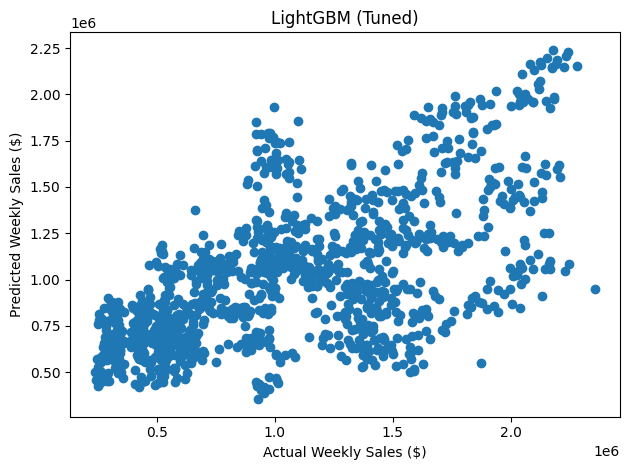

In [ ]:
best_lgb = LGBMRegressor(
    **study.best_params,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
best_lgb.fit(X_train, y_train)
y_pred_lgb_tuned = best_lgb.predict(X_test)

evaluate_metrics("LightGBM (Tuned)", y_test, y_pred_lgb_tuned)
plot_predictions("LightGBM (Tuned)", y_test, y_pred_lgb_tuned)

In [ ]:
# import optuna
# from sklearn.neural_network import MLPRegressor
# from sklearn.model_selection import cross_val_score

# # Suppress optuna logging to keep output clean
# optuna.logging.set_verbosity(optuna.logging.WARNING)

# def objective(trial):
#     params = {
#         'hidden_layer_sizes': trial.suggest_categorical('hidden_layer_sizes', [
#             (64,), (128,), (64, 32), (128, 64), (128, 64, 32)
#         ]),
#         'activation': trial.suggest_categorical('activation', ['relu', 'tanh']),
#         'alpha': trial.suggest_float('alpha', 1e-5, 1e-1, log=True),
#         'learning_rate_init': trial.suggest_float('learning_rate_init', 1e-4, 1e-2, log=True),
#         'max_iter': 500,
#         'random_state': 42
#     }

#     model = MLPRegressor(**params)

#     # Negative RMSE as the objective (Optuna minimises by default)
#     scores = cross_val_score(
#         model, X_scaled_train, y_scaled_train,
#         cv=5, scoring='neg_root_mean_squared_error'
#     )
#     return -scores.mean()

# study = optuna.create_study(direction='minimize')
# study.optimize(objective, n_trials=20, show_progress_bar=True)

# print("Best params:", study.best_params)
# print(f"Best CV RMSE (scaled): {study.best_value:.4f}")

In [ ]:
# best_nn = MLPRegressor(
#     **{k: v for k, v in study.best_params.items()},
#     max_iter=500,
#     random_state=42
# )
# best_nn.fit(X_scaled_train, y_scaled_train)
# y_pred_nn_tuned = inverse_transform(best_nn.predict(X_scaled_test))

# evaluate_metrics("Neural Network - MLP (Tuned)", y_test_dollars, y_pred_nn_tuned)
# plot_predictions("Neural Network - MLP (Tuned)", y_test_dollars, y_pred_nn_tuned)

In [ ]:
comparison_results = pd.DataFrame({
    'Model': [
        'Linear Regression (Baseline)',
        'SVR (Baseline)',
        'Neural Network (Baseline)',
        'Random Forest (Baseline)',
        'XGBoost (Baseline)',
        'LightGBM (Baseline)',
        'Random Forest (Tuned)',
        'XGBoost (Tuned)',
        'LightGBM (Tuned)',
        'AdaBoost (Baseline)',
    ],
    'MAE ($)': [
        mean_absolute_error(y_test_dollars, y_pred_lr),
        mean_absolute_error(y_test_dollars, y_pred_svr),
        mean_absolute_error(y_test_dollars, y_pred_nn),
        rf_mae, xgb_mae, lgb_mae,
        mean_absolute_error(y_test, y_pred_rf_tuned),
        mean_absolute_error(y_test, y_pred_xgb_tuned),
        mean_absolute_error(y_test, y_pred_lgb_tuned),
        ada_mae,
    ],
    'RMSE ($)': [
        np.sqrt(mean_squared_error(y_test_dollars, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test_dollars, y_pred_svr)),
        np.sqrt(mean_squared_error(y_test_dollars, y_pred_nn)),
        rf_rmse, xgb_rmse, lgb_rmse,
        np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned)),
        np.sqrt(mean_squared_error(y_test, y_pred_xgb_tuned)),
        np.sqrt(mean_squared_error(y_test, y_pred_lgb_tuned)),
        ada_rmse,
    ],
    'R²': [
        r2_score(y_test_dollars, y_pred_lr),
        r2_score(y_test_dollars, y_pred_svr),
        r2_score(y_test_dollars, y_pred_nn),
        rf_r2, xgb_r2, lgb_r2,
        r2_score(y_test, y_pred_rf_tuned),
        r2_score(y_test, y_pred_xgb_tuned),
        r2_score(y_test, y_pred_lgb_tuned),
        ada_r2,
    ]
})

comparison_results = comparison_results.sort_values('R²', ascending=False).reset_index(drop=True)

comparison_results

,Model,MAE ($),RMSE ($),R²
0,XGBoost (Tuned),313769.351851,400185.426770,0.436190
1,Random Forest (Tuned),329845.449769,401885.915064,0.431388
2,Random Forest (Baseline),339132.025025,408522.191658,0.412454
3,XGBoost (Baseline),322475.574121,414922.022019,0.393901
4,LightGBM (Baseline),329705.440294,414998.637606,0.393677
5,LightGBM (Tuned),324666.205640,417012.301601,0.387779
6,AdaBoost (Baseline),385361.129115,455438.506846,0.269753
7,Neural Network (Baseline),398762.087496,496006.119798,0.133867
8,Linear Regression (Baseline),417687.132177,505588.320937,0.100079
9,SVR (Baseline),435539.611357,548701.285601,-0.059943


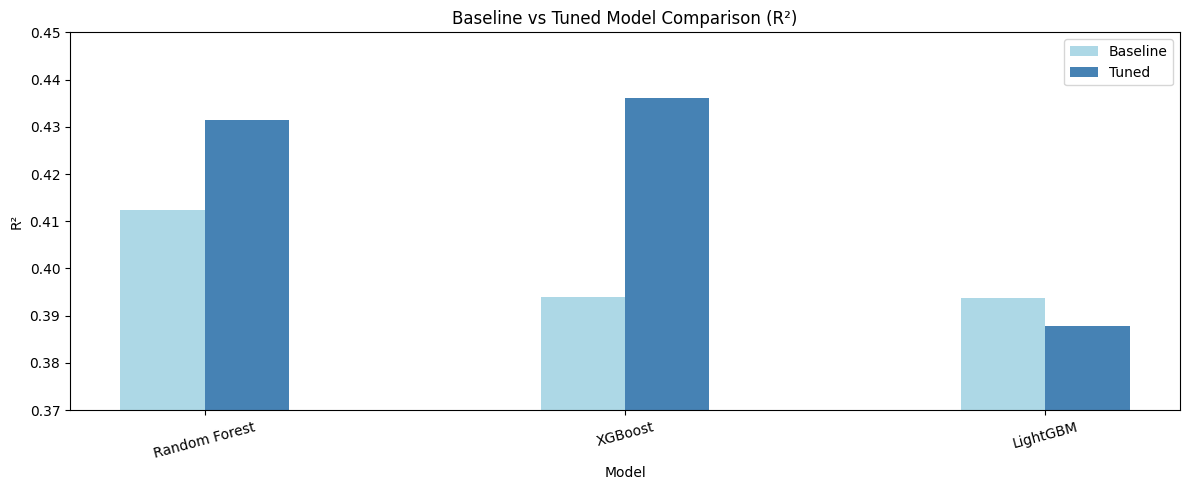

In [ ]:
models = ['Random Forest', 'XGBoost', 'LightGBM']

baseline_r2  = [
    rf_r2, xgb_r2, lgb_r2
]

tuned_r2 = [
    r2_score(y_test, y_pred_rf_tuned),
    r2_score(y_test, y_pred_xgb_tuned),
    r2_score(y_test, y_pred_lgb_tuned),
]

x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 5))

bars1 = ax.bar(x - width/2, baseline_r2, width, label='Baseline', color='lightblue')
bars2 = ax.bar(x + width/2, [v if v is not None else 0 for v in tuned_r2], width, label='Tuned', color='steelblue')

ax.set_xlabel('Model')
ax.set_ylabel('R²')
ax.set_title('Baseline vs Tuned Model Comparison (R²)')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15)
ax.legend()
ax.set_ylim(0.37, 0.45)

plt.tight_layout()
plt.show()